# CLIP Performance Analysis (using OpenCLIP)

This notebook organizes the code to replicate key findings of CLIP using the `open-clip-torch` library. We will perform three main analyses:

1.  **Zero-Shot Evaluation:** Testing the model's out-of-the-box performance using only text prompts (`k=0`).
2.  **Full Linear-Probe Evaluation:** Testing the quality of the image features by training a classifier on the *entire* training set (`k=ALL`).
3.  **Few-Shot Evaluation:** Testing the data-efficiency of the features by training a classifier on `k=1, 2, 4, 8, 16` samples per class.

Finally, we will visualize these results by loading the `.json` files generated by each analysis.

## 1. Setup & Imports

First, we import all necessary libraries. We have replaced `clip` with `open_clip`.

In [2]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0" # Uncomment and set if needed
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import torch
import open_clip
import numpy as np
import json
import time
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
from dataset_helpers import FLOWERS102_CLASS_NAMES
# Import all datasets
from torchvision.datasets import (
    CIFAR100, Food101, Flowers102, DTD, EuroSAT,
    STL10, FGVCAircraft, MNIST, Country211
)

# Import Scikit-learn for linear/few-shot
from sklearn.linear_model import LogisticRegression

# Suppress warnings
warnings.filterwarnings("ignore")
print("All libraries imported.")

All libraries imported.


## 2. Global Configuration & Helper Data

We define our constants and load the OpenCLIP model here. We use the `'ViT-B-32'` architecture with `'openai'` pretrained weights to replicate the original paper's results.

In [3]:
# --- Global Constants ---
MODEL_NAME = "ViT-B-32"
PRETRAINED_TAG = "openai"
BATCH_SIZE = 128
DATA_ROOT = os.path.expanduser("~/.cache")
LOGISTIC_REGRESSION_C = 0.316 # From the paper's README
K_SHOTS = [1, 2, 4, 8, 16] # For few-shot analysis

# --- Result File Names ---
ZERO_SHOT_RESULTS_FILE = "zero_shot_results_lib.json"
LINEAR_PROBE_RESULTS_FILE = "linear_probe_results_lib.json"
FEW_SHOT_RESULTS_FILE = "few_shot_results_lib.json"

# --- Load OpenCLIP Model Once ---
print(f"Loading OpenCLIP model: {MODEL_NAME} ({PRETRAINED_TAG})")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Use create_model_and_transforms for OpenCLIP
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED_TAG, device=DEVICE)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model.eval() # Ensure model is in eval mode
print(f"Model loaded and running on {DEVICE}.")

Loading OpenCLIP model: ViT-B-32 (openai)


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Model loaded and running on cuda.


## 3. Shared Helper Functions

These are the core functions for feature extraction and classification.

In [4]:
def extract_features(dataset, model):
    """
    Extracts CLIP features, normalizes them, and returns as numpy arrays.
    """
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(DEVICE)
            # OpenCLIP encode_image works the same way
            features = model.encode_image(images)
            
            # L2-normalize features
            features /= features.norm(dim=-1, keepdim=True)
            
            all_features.append(features.cpu())
            all_labels.append(labels.cpu())

    return torch.cat(all_features).numpy(), torch.cat(all_labels).numpy()

def train_classifier(train_features, train_labels, verbose=1):
    """
    Trains a linear classifier on the extracted features.
    """
    print("Training linear classifier...")
    classifier = LogisticRegression(
        random_state=0, 
        C=LOGISTIC_REGRESSION_C, 
        max_iter=1000, 
        verbose=verbose, 
        n_jobs=-1,
        solver='lbfgs'
    )
    classifier.fit(train_features, train_labels)
    return classifier

def evaluate_classifier(classifier, test_features, test_labels):
    """
    Evaluates the trained classifier on the test set.
    """
    print("Evaluating classifier...")
    predictions = classifier.predict(test_features)
    accuracy = np.mean((test_labels == predictions).astype(float)) * 100.
    return accuracy, len(test_labels)

def load_results(filename):
    if not os.path.exists(filename):
        print(f"Warning: Results file not found: {filename}")
        return {}
    try:
        with open(filename, 'r') as f:
            data = json.load(f)
        return data.get("scores", {})
    except Exception as e:
        print(f"Error loading {filename}: {e}")
        return {}

--- 

# ANALYSIS 1: Zero-Shot Evaluation

This experiment tests CLIP's ability to classify images using only natural language prompts.

**Changes for OpenCLIP:** We now use the `tokenizer` we loaded earlier instead of `clip.tokenize`.

In [5]:
# --- Prompt Templates for Analysis 1 ---
from dataset_helpers import GENERAL_TEMPLATES
from dataset_helpers import DTD_TEMPLATES
from dataset_helpers import EUROSAT_TEMPLATES
from dataset_helpers import FGVC_TEMPLATES
from dataset_helpers import MNIST_TEMPLATES

# --- Dataset Configuration for Analysis 1 ---

ZERO_SHOT_DATASET_CONFIG = {
    "CIFAR100": {
        "loader": lambda p: CIFAR100(root=DATA_ROOT, download=True, train=False, transform=p),
        "class_getter": lambda ds: ds.classes,
        "templates": GENERAL_TEMPLATES
    },
    "Food101": {
        "loader": lambda p: Food101(root=DATA_ROOT, download=True, split='test', transform=p),
        "class_getter": lambda ds: ds.classes,
        "templates": GENERAL_TEMPLATES
    },
    "Flowers102": {
        "loader": lambda p: Flowers102(root=DATA_ROOT, download=True, split='test', transform=p),
        "class_getter": lambda ds: FLOWERS102_CLASS_NAMES,
        "templates": GENERAL_TEMPLATES
    },
    "DTD": {
        "loader": lambda p: DTD(root=DATA_ROOT, download=True, split='test', transform=p),
        "class_getter": lambda ds: ds.classes,
        "templates": DTD_TEMPLATES
    },
    "EuroSAT": {
        "loader": lambda p: EuroSAT(root=DATA_ROOT, download=True, transform=p),
        "class_getter": lambda ds: ds.classes,
        "templates": EUROSAT_TEMPLATES
    },
    "STL10": {
        "loader": lambda p: STL10(root=DATA_ROOT, download=True, split='test', transform=p),
        "class_getter": lambda ds: ds.classes,
        "templates": GENERAL_TEMPLATES
    },
    "FGVCAircraft": {
        "loader": lambda p: FGVCAircraft(root=DATA_ROOT, download=True, split='test', transform=p),
        "class_getter": lambda ds: ds.classes,
        "templates": FGVC_TEMPLATES
    },
    "MNIST": {
        "loader": lambda p: MNIST(root=DATA_ROOT, download=True, train=False, transform=p),
        "class_getter": lambda ds: ds.classes,
        "templates": MNIST_TEMPLATES
    },
    "Country211": {
        "loader": lambda p: Country211(root=DATA_ROOT, download=True, split='test', transform=p),
        "class_getter": lambda ds: ds.classes,
        "templates": GENERAL_TEMPLATES
    },
}

def get_zeroshot_classifier(model, tokenizer, templates, class_names):
    """
    Creates zero-shot classifier weights by encoding
    text prompts for all class names.
    """
    all_text_features = []
    
    print(f"Building zero-shot classifier for {len(class_names)} classes...")
    with torch.no_grad():
        for class_name in tqdm(class_names, desc="Encoding class names"):
            texts = [template.format(class_name) for template in templates]
            # Use OpenCLIP tokenizer
            text_tokens = tokenizer(texts).to(DEVICE)
            
            text_features = model.encode_text(text_tokens)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            text_features = text_features.mean(dim=0)
            text_features /= text_features.norm()
            
            all_text_features.append(text_features)
            
    text_classifier = torch.stack(all_text_features, dim=0).to(DEVICE)
    return text_classifier

def run_zeroshot_evaluation(model, text_classifier, dataloader):
    """
    Evaluates the model on the given dataloader using the
    pre-built zero-shot text classifier.
    """
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            logits = (100.0 * image_features @ text_classifier.T)
            _, predictions = logits.max(1)
            
            total_correct += (predictions == labels).sum().item()
            total_samples += images.size(0)
            
    accuracy = (total_correct / total_samples) * 100.0
    return accuracy, total_correct, total_samples

### ► Run Analysis 1

In [6]:
def main_analysis_1():
    all_results = {
        "model": MODEL_NAME,
        "pretrained": PRETRAINED_TAG,
        "evaluation_time": time.time(),
        "scores": {}
    }

    for dataset_name, config in ZERO_SHOT_DATASET_CONFIG.items():
        print(f"\n--- Evaluating Dataset: {dataset_name} ---")

        try:
            dataset = config["loader"](preprocess)
            dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
            
            class_names = config["class_getter"](dataset)
            if class_names is None:
                raise ValueError("Class names could not be loaded.")
            
            print(f"Total test samples: {len(dataset)}, Classes: {len(class_names)}")
            
            # Pass tokenizer explicitly
            text_classifier = get_zeroshot_classifier(model, tokenizer, config["templates"], class_names)
            
            accuracy, correct, total = run_zeroshot_evaluation(model, text_classifier, dataloader)
            
            all_results["scores"][dataset_name] = {
                "accuracy": accuracy,
                "correct": correct,
                "total": total,
                "class_count": len(class_names)
            }
            print(f"Accuracy for {dataset_name}: {accuracy:.3f}%")

        except Exception as e:
            print(f"!!! FAILED to evaluate {dataset_name} !!!")
            print(f"Error: {e}")
            all_results["scores"][dataset_name] = f"FAILED ({e})"
    
    with open(ZERO_SHOT_RESULTS_FILE, 'w') as f:
        json.dump(all_results, f, indent=4)
    print(f"\nAll zero-shot results saved to {ZERO_SHOT_RESULTS_FILE}")

# Set to True to run the analysis
if True: 
    main_analysis_1()
else:
    print("Skipping Analysis 1. Set 'if False' to 'if True' to run.")


--- Evaluating Dataset: CIFAR100 ---
Files already downloaded and verified
Total test samples: 10000, Classes: 100
Building zero-shot classifier for 100 classes...


Evaluating: 100%|██████████| 79/79 [00:11<00:00,  7.13it/s]


Accuracy for CIFAR100: 62.310%

--- Evaluating Dataset: Food101 ---
Total test samples: 25250, Classes: 101
Building zero-shot classifier for 101 classes...


Evaluating: 100%|██████████| 198/198 [00:56<00:00,  3.53it/s]


Accuracy for Food101: 76.499%

--- Evaluating Dataset: Flowers102 ---
Total test samples: 6149, Classes: 105
Building zero-shot classifier for 105 classes...


...

Accuracy for FGVCAircraft: 15.932%

--- Evaluating Dataset: MNIST ---
Total test samples: 10000, Classes: 10
Building zero-shot classifier for 10 classes...


Evaluating: 100%|██████████| 79/79 [00:09<00:00,  8.55it/s]


Accuracy for MNIST: 36.550%

--- Evaluating Dataset: Country211 ---
Total test samples: 21100, Classes: 211
Building zero-shot classifier for 211 classes...


Evaluating: 100%|██████████| 165/165 [01:03<00:00,  2.61it/s]

Accuracy for Country211: 1.526%

All zero-shot results saved to zero_shot_results_lib.json


--- 

# ANALYSIS 2: Full Linear-Probe Evaluation

This remains largely unchanged as `extract_features` handles the OpenCLIP differences.

In [7]:
# --- Dataset Configuration for Analysis 2 ---

LINEAR_PROBE_DATASET_CONFIG = {
    "CIFAR100": {
        "train": lambda p: CIFAR100(root=DATA_ROOT, download=True, train=True, transform=p),
        "test": lambda p: CIFAR100(root=DATA_ROOT, download=True, train=False, transform=p),
    },
    "Food101": {
        "train": lambda p: Food101(root=DATA_ROOT, download=True, split='train', transform=p),
        "test": lambda p: Food101(root=DATA_ROOT, download=True, split='test', transform=p),
    },
    "Flowers102": {
        "train": lambda p: Flowers102(root=DATA_ROOT, download=True, split='train', transform=p),
        "test": lambda p: Flowers102(root=DATA_ROOT, download=True, split='test', transform=p),
    },
    "DTD": {
        "train": lambda p: DTD(root=DATA_ROOT, download=True, split='train', transform=p),
        "test": lambda p: DTD(root=DATA_ROOT, download=True, split='test', transform=p),
    },
    "EuroSAT": {
        "train": lambda p: EuroSAT(root=DATA_ROOT, download=True, transform=p),
        "test": lambda p: EuroSAT(root=DATA_ROOT, download=True, transform=p),
    },
    "STL10": {
        "train": lambda p: STL10(root=DATA_ROOT, download=True, split='train', transform=p),
        "test": lambda p: STL10(root=DATA_ROOT, download=True, split='test', transform=p),
    },
    "FGVCAircraft": {
        "train": lambda p: FGVCAircraft(root=DATA_ROOT, download=True, split='train', transform=p),
        "test": lambda p: FGVCAircraft(root=DATA_ROOT, download=True, split='test', transform=p),
    },
    "MNIST": {
        "train": lambda p: MNIST(root=DATA_ROOT, download=True, train=True, transform=p),
        "test": lambda p: MNIST(root=DATA_ROOT, download=True, train=False, transform=p),
    },
    "Country211": {
        "train": lambda p: Country211(root=DATA_ROOT, download=True, split='train', transform=p),
        "test": lambda p: Country211(root=DATA_ROOT, download=True, split='test', transform=p),
    },
   
}

### ► Run Analysis 2

In [8]:
def main_analysis_2():
    all_results = {
        "model": MODEL_NAME,
        "pretrained": PRETRAINED_TAG,
        "evaluation_time": time.time(),
        "scores": {}
    }

    for dataset_name, config in LINEAR_PROBE_DATASET_CONFIG.items():
        print(f"\n--- Evaluating Dataset: {dataset_name} ---")

        try:
            train_dataset = config["train"](preprocess)
            test_dataset = config["test"](preprocess)
            print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

            print("Extracting features for training set...")
            train_features, train_labels = extract_features(train_dataset, model)
            print("Extracting features for test set...")
            test_features, test_labels = extract_features(test_dataset, model)
            
            print(f"Train features shape: {train_features.shape}")
            print(f"Test features shape: {test_features.shape}")

            classifier = train_classifier(train_features, train_labels, verbose=1)
            
            accuracy, total = evaluate_classifier(classifier, test_features, test_labels)
            
            all_results["scores"][dataset_name] = {
                "accuracy": accuracy,
                "total_test_samples": total,
                "train_samples": len(train_dataset),
            }
            print(f"Accuracy for {dataset_name}: {accuracy:.3f}%")

        except Exception as e:
            print(f"!!! FAILED to evaluate {dataset_name} !!!")
            print(f"Error: {e}")
            all_results["scores"][dataset_name] = f"FAILED ({e})"
    
    with open(LINEAR_PROBE_RESULTS_FILE, 'w') as f:
        json.dump(all_results, f, indent=4)
    print(f"\nAll linear-probe results saved to {LINEAR_PROBE_RESULTS_FILE}")

# Set to True to run the analysis
if True:
    main_analysis_2()
else:
    print("Skipping Analysis 2. Set 'if False' to 'if True' to run.")


--- Evaluating Dataset: CIFAR100 ---
Files already downloaded and verified
Files already downloaded and verified
Train samples: 50000, Test samples: 10000
Extracting features for training set...


Extracting features: 100%|██████████| 391/391 [00:46<00:00,  8.49it/s]


Extracting features for test set...


Extracting features: 100%|██████████| 79/79 [00:11<00:00,  6.86it/s]


Train features shape: (50000, 512)
Test features shape: (10000, 512)
Training linear classifier...


...

Extracting features for test set...


Extracting features: 100%|██████████| 165/165 [01:02<00:00,  2.65it/s]


Train features shape: (31650, 512)
Test features shape: (21100, 512)
Training linear classifier...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.


Evaluating classifier...
Accuracy for Country211: 17.137%

All linear-probe results saved to linear_probe_results_lib.json


--- 

# ANALYSIS 3: Few-Shot Evaluation

This relies on the same `extract_features` and standard scikit-learn, so no changes needed here either beyond what was done in Setup.

In [9]:
# --- Dataset Configuration for Analysis 3 ---
FEW_SHOT_DATASET_CONFIG = LINEAR_PROBE_DATASET_CONFIG

# --- Helper Functions for Analysis 3 ---

def get_k_shot_indices(dataset, k):
    """
    Sub-samples a dataset to get exactly k samples per class.
    """
    indices_per_class = {}
    
    print(f"Sampling {k}-shot indices...")
    targets = []
    if hasattr(dataset, 'targets'):
        targets = dataset.targets
    elif hasattr(dataset, '_labels'):
        targets = dataset._labels
    elif hasattr(dataset, '_samples'): # For ImageFolder-like
        targets = [s[1] for s in dataset._samples]
    else: # Fallback for datasets like DTD
        print("Dataset has no standard target attribute, iterating...")
        targets = [label for _, label in tqdm(dataset)]

    if not targets:
        raise ValueError("Could not extract labels from dataset.")

    for idx, target in enumerate(targets):
        if target not in indices_per_class:
            indices_per_class[target] = []
        if len(indices_per_class[target]) < k:
            indices_per_class[target].append(idx)
            
    final_indices = [idx for class_indices in indices_per_class.values() for idx in class_indices]
    
    num_classes = len(indices_per_class)
    print(f"Sampled {len(final_indices)} total indices for {k} shots across {num_classes} classes.")
    return final_indices

### ► Run Analysis 3

In [10]:
def main_analysis_3():
    all_results = {
        "model": MODEL_NAME,
        "pretrained": PRETRAINED_TAG,
        "evaluation_time": time.time(),
        "scores": {}
    }

    # --- Pre-extract all features to speed up k-shot loop ---
    test_features_cache = {}
    test_labels_cache = {}
    train_features_cache = {}
    train_labels_cache = {}
    train_dataset_cache = {} # Store datasets to sample from
    
    print("--- Pre-extracting ALL features (this will take a while) ---")
    for dataset_name, config in FEW_SHOT_DATASET_CONFIG.items():
        try:
            print(f"\nLoading features for {dataset_name}...")
            train_dataset = config["train"](preprocess)
            test_dataset = config["test"](preprocess)
            
            train_features_cache[dataset_name], train_labels_cache[dataset_name] = extract_features(train_dataset, model)
            test_features_cache[dataset_name], test_labels_cache[dataset_name] = extract_features(test_dataset, model)
            train_dataset_cache[dataset_name] = train_dataset # Save dataset object for sampling
            
            print(f"Features for {dataset_name} cached.")
        except Exception as e:
            print(f"!!! FAILED to cache features for {dataset_name}: {e} !!!")

    # --- Main K-Shot Evaluation Loop ---
    print("\n--- Starting Few-Shot Evaluation Loop ---")
    
    for dataset_name in train_features_cache.keys(): # Iterate only over cached datasets
        print(f"\n--- Evaluating Dataset: {dataset_name} ---")
        all_results["scores"][dataset_name] = {}
        
        for k in K_SHOTS:
            try:
                print(f"  Running {k}-shot evaluation...")
                k_shot_indices = get_k_shot_indices(train_dataset_cache[dataset_name], k)
                
                k_shot_features = train_features_cache[dataset_name][k_shot_indices]
                k_shot_labels = train_labels_cache[dataset_name][k_shot_indices]
                
                classifier = train_classifier(k_shot_features, k_shot_labels, verbose=0) # No verbose
                
                accuracy, _ = evaluate_classifier(classifier, test_features_cache[dataset_name], test_labels_cache[dataset_name])
                print(f"  Accuracy for {k}-shot: {accuracy:.3f}%")
                all_results["scores"][dataset_name][f"{k}-shot"] = accuracy

            except Exception as e:
                print(f"!!! FAILED {k}-shot for {dataset_name}: {e} !!!")
                all_results["scores"][dataset_name][f"{k}-shot"] = f"FAILED ({e})"
    
    with open(FEW_SHOT_RESULTS_FILE, 'w') as f:
        json.dump(all_results, f, indent=4)
    print(f"\nAll few-shot results saved to {FEW_SHOT_RESULTS_FILE}")

# Set to True to run the analysis
if True:
    main_analysis_3()
else:
    print("Skipping Analysis 3. Set 'if False' to 'if True' to run.")

--- Pre-extracting ALL features (this will take a while) ---

Loading features for CIFAR100...
Files already downloaded and verified
Files already downloaded and verified


Extracting features: 100%|██████████| 79/79 [00:09<00:00,  8.33it/s]


Features for CIFAR100 cached.

Loading features for Food101...


Extracting features: 100%|██████████| 198/198 [00:55<00:00,  3.57it/s]


Features for Food101 cached.

Loading features for Flowers102...


...

Sampled 40 total indices for 4 shots across 10 classes.
Training linear classifier...
Evaluating classifier...
  Accuracy for 4-shot: 92.425%
  Running 8-shot evaluation...
Sampling 8-shot indices...
Dataset has no standard target attribute, iterating...


100%|██████████| 5000/5000 [00:09<00:00, 529.09it/s]


Sampled 80 total indices for 8 shots across 10 classes.
Training linear classifier...
Evaluating classifier...
  Accuracy for 8-shot: 95.638%
  Running 16-shot evaluation...
Sampling 16-shot indices...
Dataset has no standard target attribute, iterating...


100%|██████████| 5000/5000 [00:09<00:00, 535.94it/s]


Sampled 160 total indices for 16 shots across 10 classes.
Training linear classifier...
Evaluating classifier...
  Accuracy for 16-shot: 96.075%

--- Evaluating Dataset: FGVCAircraft ---
  Running 1-shot evaluation...
Sampling 1-shot indices...
Sampled 100 total indices for 1 shots across 100 classes.
Training linear classifier...
Evaluating classifier...
  Accuracy for 1-shot: 14.671%
  Running 2-shot evaluation...
Sampling 2-shot indices...
Sampled 200 total indices for 2 shots across 100 classes.
Training linear classifier...
Evaluating classifier...
  Accuracy for 2-shot: 18.422%
  Running 4-shot evaluation...
Sampling 4-shot indices...
Sampled 400 total indices for 4 shots across 100 classes.
Training linear classifier...
Evaluating classifier...
  Accuracy for 4-shot: 18.272%
  Running 8-shot evaluation...
Sampling 8-shot indices...
Sampled 800 total indices for 8 shots across 100 classes.
Training linear classifier...
Evaluating classifier...
  Accuracy for 8-shot: 19.982%
  Run

--- 

# VISUALIZATIONS

The visualization code remains exactly the same.

In [11]:
# --- Paper's Reported Scores for ViT-B/32 ---
PAPER_SCORES = {
    "Zero-Shot": {
        "CIFAR100": 64.2,
        "Food101": 83.3,
        "Flowers102": 66.6,
        "DTD": 42.9,
        "EuroSAT": 40.6,
        "STL10": 97.1,
        "FGVCAircraft": 22.5,
        "MNIST": 29.8,
        "Country211": 23.2,
    },
    "Linear-Probe": {
        "CIFAR100": 80.1,
        "Food101": 88.2,
        "Flowers102": 93.2,
        "DTD": 73.4,
        "EuroSAT": 97.2,
        "STL10": 98.6,
        "FGVCAircraft": 62.0,
        "MNIST": 98.4,
    }
}

# --- Plot A: Zero-Shot vs. Linear-Probe Gain ---
def plot_zeroshot_vs_linear(zs_results, lp_results):
    print("--- Generating Plot A: Zero-Shot vs. Linear-Probe Gain ---")
    datasets = sorted(lp_results.keys()) 
    
    zs_scores = []
    lp_scores = []
    labels = []

    for ds in datasets:
        if ds in zs_results and isinstance(zs_results[ds], dict) and isinstance(lp_results[ds], dict):
            zs_scores.append(zs_results[ds]['accuracy'])
            lp_scores.append(lp_results[ds]['accuracy'])
            labels.append(ds)
    
    if not labels:
        print("No common valid results to plot for ZeroShot vs Linear.")
        return

    y = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.barh(y - width/2, zs_scores, width, label='Zero-Shot (k=0)', color='blue')
    ax.barh(y + width/2, lp_scores, width, label='Full Linear-Probe (k=ALL)', color='orange')
    
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Accuracy (%)')
    ax.set_title('Zero-Shot vs. Full Linear-Probe Performance')
    ax.legend()
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    ax.set_xlim(0, 100)
    
    for i, (zs, lp) in enumerate(zip(zs_scores, lp_scores)):
        ax.text(zs + 1, y[i] - width/2, f'{zs:.1f}', va='center', ha='left', fontsize=8)
        ax.text(lp + 1, y[i] + width/2, f'{lp:.1f}', va='center', ha='left', fontsize=8, color='darkorange')
        
    plt.tight_layout()
    plt.savefig("zeroshot_vs_linear_analysis_library.png", dpi=300)
    print("Plot saved to zeroshot_vs_linear_analysis_library.png")
    plt.show()

# --- Plot B: Replication Analysis (vs. Paper) ---
def plot_replication_analysis(zs_results, lp_results):
    print("--- Generating Plot B: Replication Analysis vs. Paper ---")
    
    paper_zs_keys = set(PAPER_SCORES["Zero-Shot"].keys())
    paper_lp_keys = set(PAPER_SCORES["Linear-Probe"].keys())
    local_zs_keys = set(k for k,v in zs_results.items() if isinstance(v, dict))
    local_lp_keys = set(k for k,v in lp_results.items() if isinstance(v, dict))
    
    all_datasets = sorted(list((paper_zs_keys | paper_lp_keys | local_zs_keys | local_lp_keys)))
    
    local_scores = []
    paper_scores = []
    labels = []
    
    for ds in all_datasets:
        if ds in zs_results and isinstance(zs_results[ds], dict) and ds in PAPER_SCORES["Zero-Shot"]:
            local_scores.append(zs_results[ds]['accuracy'])
            paper_scores.append(PAPER_SCORES["Zero-Shot"][ds])
            labels.append(f"{ds} (Zero-Shot)")
            
    for ds in all_datasets:
        if ds in lp_results and isinstance(lp_results[ds], dict) and ds in PAPER_SCORES["Linear-Probe"]:
            local_scores.append(lp_results[ds]['accuracy'])
            paper_scores.append(PAPER_SCORES["Linear-Probe"][ds])
            labels.append(f"{ds} (Linear-Probe)")
    
    y = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, len(labels) * 0.5))
    ax.barh(y - width/2, paper_scores, width, label=f"Paper (ViT-B/32)", color='gray', alpha=0.8)
    ax.barh(y + width/2, local_scores, width, label='My Replication', color='green')
    
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Accuracy (%)')
    ax.set_title('Replication Analysis: My Results vs. Paper')
    ax.legend()
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    ax.set_xlim(0, 100)

    plt.tight_layout()
    plt.savefig("replication_analysis_grouped_library.png", dpi=300)
    print("Plot saved to replication_analysis_grouped_library.png")
    plt.show()

# --- Plot C: Few-Shot vs. Zero-Shot (Figure 5) ---
def plot_few_shot_analysis(zs_results, fs_results):
    print("--- Generating Plot C: Few-Shot Analysis (Replicating Figure 5) ---")
    
    avg_fs_scores = {k: [] for k in K_SHOTS}
    avg_zs_score_list = []
    
    datasets = sorted(fs_results.keys())
    
    for dataset_name in datasets:
        if dataset_name not in zs_results or not isinstance(zs_results.get(dataset_name), dict):
            print(f"Skipping {dataset_name}: Missing zero-shot result.")
            continue
        
        fs_data = fs_results.get(dataset_name, {})
        valid_fs_scores = True
        for k in K_SHOTS:
            if not isinstance(fs_data.get(f"{k}-shot"), (int, float)):
                valid_fs_scores = False
                break
        
        if valid_fs_scores:
            print(f"Including {dataset_name} in average.")
            avg_zs_score_list.append(zs_results[dataset_name]["accuracy"])
            for k in K_SHOTS:
                avg_fs_scores[k].append(fs_data[f"{k}-shot"])
        else:
            print(f"Skipping {dataset_name}: Missing or failed few-shot results.")

    if not avg_zs_score_list:
        print("Error: No valid common scores found between zero-shot and few-shot results.")
        return
        
    avg_zs = np.mean(avg_zs_score_list)
    avg_fs = {k: np.mean(v) if v else None for k, v in avg_fs_scores.items()}
    
    x_fs = [k for k in K_SHOTS if avg_fs[k] is not None]
    y_fs = [avg_fs[k] for k in x_fs]

    print(f"Average Zero-Shot Accuracy: {avg_zs:.2f}%")
    for k, v in zip(x_fs, y_fs):
        print(f"Average {k}-Shot Accuracy: {v:.2f}%")

    plt.figure(figsize=(10, 6))
    plt.plot(x_fs, y_fs, marker='o', linestyle='-', label=f"Average {len(avg_zs_score_list)}-Dataset Linear-Probe")
    plt.axhline(y=avg_zs, color='r', linestyle='--', label=f"Average {len(avg_zs_score_list)}-Dataset Zero-Shot ({avg_zs:.2f}%)")
    
    try:
        for i in range(len(x_fs) - 1):
            if y_fs[i] < avg_zs and y_fs[i+1] > avg_zs:
                x1, y1 = x_fs[i], y_fs[i]
                x2, y2 = x_fs[i+1], y_fs[i+1]
                cross_x = x1 + (x2 - x1) * (avg_zs - y1) / (y2 - y1)
                plt.axvline(x=cross_x, color='gray', linestyle=':', label=f"Crosses at {cross_x:.1f}-shot")
                break
    except Exception as e:
        print(f"Could not calculate intersection: {e}")

    plt.xlabel('# of Labeled Training Examples per Class (k-shot)')
    plt.ylabel('Average Score (%)')
    plt.title('Few-Shot vs. Zero-Shot Performance')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(K_SHOTS)
    
    plt.tight_layout()
    plt.savefig("few_shot_analysis_library.png", dpi=300)
    print(f"Plot saved to few_shot_analysis_library.png")
    plt.show()

### ► Run All Visualizations

Loading local results...
--- Generating Plot A: Zero-Shot vs. Linear-Probe Gain ---
Plot saved to zeroshot_vs_linear_analysis_library.png


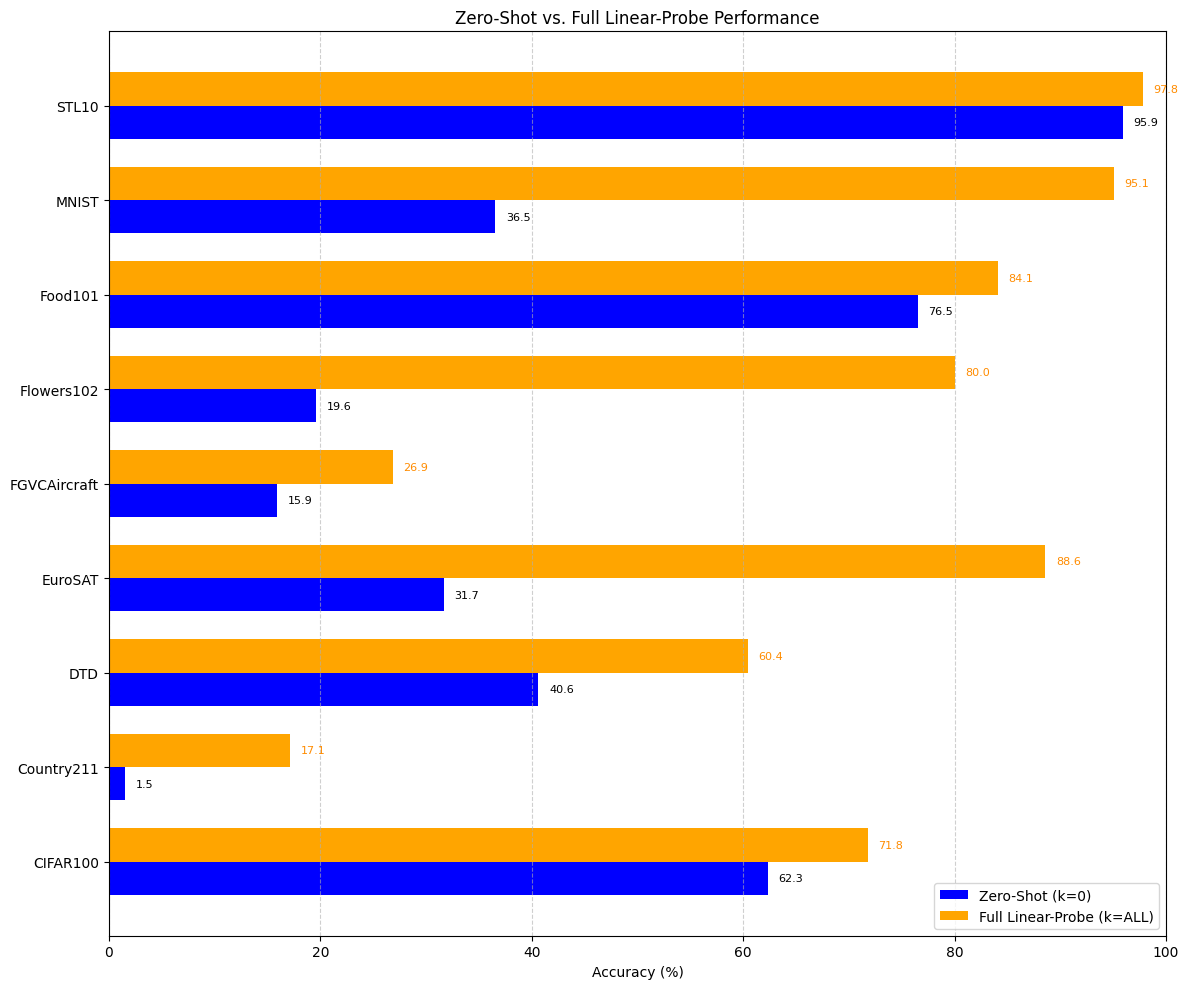

--- Generating Plot B: Replication Analysis vs. Paper ---
Plot saved to replication_analysis_grouped_library.png


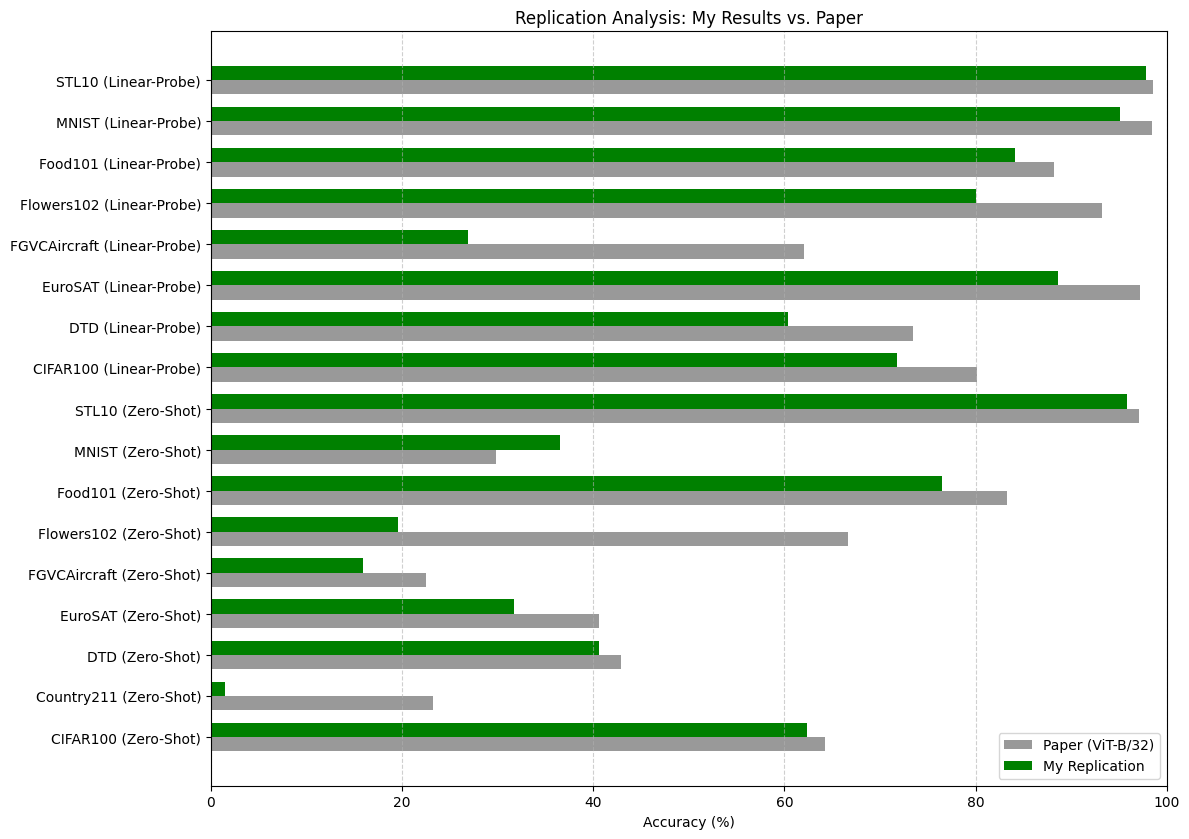

--- Generating Plot C: Few-Shot Analysis (Replicating Figure 5) ---
Including CIFAR100 in average.
Including Country211 in average.
Including DTD in average.
Including EuroSAT in average.
Including FGVCAircraft in average.
Including Flowers102 in average.
Including Food101 in average.
Skipping MNIST: Missing or failed few-shot results.
Including STL10 in average.
Average Zero-Shot Accuracy: 43.01%
Average 1-Shot Accuracy: 36.69%
Average 2-Shot Accuracy: 43.64%
Average 4-Shot Accuracy: 48.70%
Average 8-Shot Accuracy: 52.36%
Average 16-Shot Accuracy: 56.07%
Plot saved to few_shot_analysis_library.png


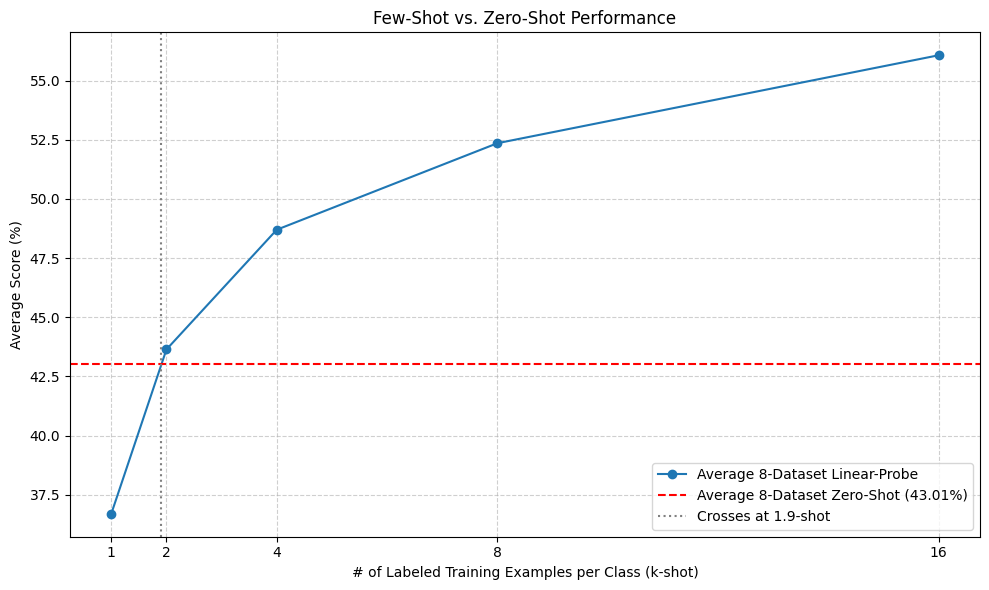

In [12]:
print("Loading local results...")
local_zs_results = load_results(ZERO_SHOT_RESULTS_FILE)
local_lp_results = load_results(LINEAR_PROBE_RESULTS_FILE)
local_fs_results = load_results(FEW_SHOT_RESULTS_FILE)

if not local_zs_results and not local_lp_results and not local_fs_results:
    print("\nError: All results files are missing.")
    print("Please run the 'main_analysis_X' cells above.")
else:
    if local_zs_results and local_lp_results:
        plot_zeroshot_vs_linear(local_zs_results, local_lp_results)
    else:
        print("\nSkipping Plot A: Missing zero_shot_results.json or linear_probe_results.json.")
        
    plot_replication_analysis(local_zs_results, local_lp_results)
    
    if local_zs_results and local_fs_results:
        plot_few_shot_analysis(local_zs_results, local_fs_results)
    else:
        print("\nSkipping Plot C: Missing zero_shot_results.json or few_shot_results.json.")